In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
 

 
 


In [2]:
# Set the seed for reproducibility
np.random.seed(42)

In [3]:
# Creamos nuestros datos artificiales (dos círculos concéntricos)
X, Y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

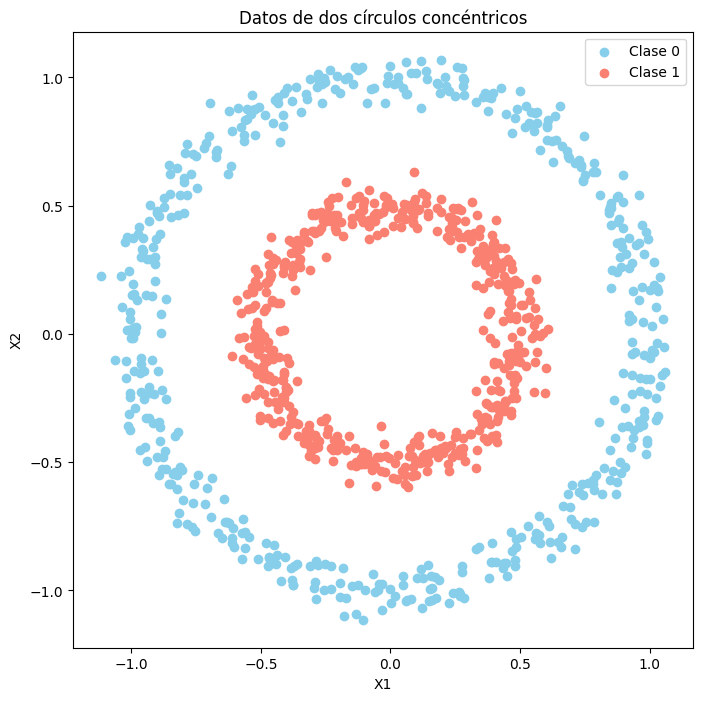

In [4]:
# Visualización de los datos generados
plt.figure(figsize=(8, 8))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], c="skyblue", label="Clase 0")
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], c="salmon", label="Clase 1")
plt.title("Datos de dos círculos concéntricos")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# dividir en 85 % entrenamiento / 15 % test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.15, random_state=42, stratify=Y
)

print(f"tamaño train: {X_train.shape[0]}, test: {X_test.shape[0]}")

tamaño train: 850, test: 150


In [6]:
#Como el modelo es de clasificacion binomial quiero que uses sigmoid como funcion de activacion, y binary_crossentropy como funcion de perdida. Entrena el modelo durante 100 epocas con un batch size de 32. Ademas quiero que uses 3 capas ocultas, la primera con 16, la segunda con 8 y  la tercera con 4 neuronas. Usa el optimizador Adam con un learning rate 0.3
from tensorflow import keras
from tensorflow.keras import layers
# Crear el modelo secuencial
model = keras.Sequential(
    [
        layers.Input(shape=(2,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

In [7]:
# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [8]:
# Entrenar el modelo
history = model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_split=0.15)
# Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6306 - loss: 0.6983 - val_accuracy: 0.9844 - val_loss: 0.3413
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9439 - loss: 0.2916 - val_accuracy: 1.0000 - val_loss: 0.0879
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9893 - loss: 0.0825 - val_accuracy: 0.9922 - val_loss: 0.0392
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9949 - loss: 0.0401 - val_accuracy: 1.0000 - val_loss: 0.0164
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9939 - loss: 0.0305 - val_accuracy: 0.9922 - val_loss: 0.0239
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0102 - val_accuracy: 1.0000 - val_loss: 0.0080
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 0.0059
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 1.0000 - 

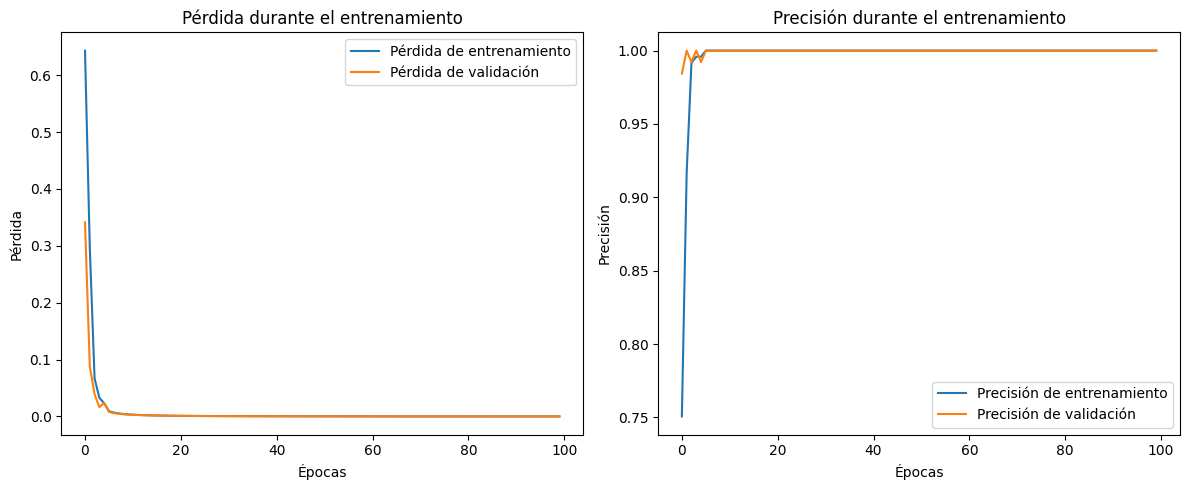

In [9]:
#Haz la grafica de la perdida y la precision durante el entrenamiento
plt.figure(figsize=(12, 5))
# Grafica de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
# Grafica de la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Precisión de entrenamiento")
plt.plot(history.history["val_accuracy"], label="Precisión de validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()
plt.tight_layout()
plt.show()
